In [1]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import pandas as pd
from tqdm import tqdm
import torch

In [2]:
model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=1024, out_features=2816, bias=False)
              (wi_1): Linear(in_features=1024, out_features=2816, bias=False)
       

In [3]:
from google.colab import files
import os
filename = "Q2_20230202_majority 1.csv"

if not os.path.exists(filename):
  print(f"'{filename}' not found. Please upload the file.")
  uploaded = files.upload()
pd.set_option('display.max_colwidth', None)

df = pd.read_csv("Q2_20230202_majority 1.csv")

In [4]:
def batched_generate(prompts, max_tokens=16, batch_size=16):
    outputs_text = []
    for i in tqdm(range(0, len(prompts), batch_size), desc="Batching"):
        batch_prompts = prompts[i:i + batch_size]
        inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True, truncation=True).to(device)
        # outputs = model.generate(**inputs, max_new_tokens=max_tokens)
        outputs = model.generate(**inputs, max_new_tokens=max_tokens, temperature=0.9, do_sample=True)
        outputs_text += tokenizer.batch_decode(outputs, skip_special_tokens=True)
    return [o.strip().lower() for o in outputs_text]


def clean_stage1_response(resp):
    return "stance" if "stance" in resp.lower() and "neutral" not in resp.lower() else "neutral-or-unclear"


In [5]:
df = df.sample(112)

In [6]:
stage1_prompts = [
    f"""
Classify the stance of the following tweet about the COVID-19 vaccine as "stance" or "neutral-or-unclear".

If the tweet shows ANY sign of support or opposition — even subtly, sarcastically, or emotionally — label it as "stance".
Only use "neutral-or-unclear" if the tweet is purely factual, ambiguous, or shows no opinion.

Example 1:
Tweet: "I'm excited to get my second dose!"
Answer: stance

Example 2:
Tweet: "Still not sure how I feel about the vaccine."
Answer: neutral-or-unclear

Example 3:
Tweet: "Just got my booster."
Answer: stance

Example 4:
Tweet: "I don't know about this vaccine stuff anymore."
Answer: stance

Example 5:
Tweet: "Vaccination starts tomorrow in my city."
Answer: neutral-or-unclear

Now classify the following:
Tweet: {tweet}

Answer:"""
    for tweet in df["tweet"]
]
stage1_outputs = batched_generate(stage1_prompts)

Batching: 100%|██████████| 7/7 [09:29<00:00, 81.42s/it]


In [7]:
for i, (tweet, pred, gold) in enumerate(zip(df["tweet"], stage1_outputs, df["label_majority"])):
    if gold == "in-favor" and clean_stage1_response(pred) == "neutral-or-unclear":
        print(f"[Filtered from stage 2] Tweet: {tweet}\nStage 1 Output: {pred}\n")


[Filtered from stage 2] Tweet: (1/2) follow covid appropriate behaviour even after getting vaccinated #covid #vaccineforall
Stage 1 Output: neutral-or-unclear

[Filtered from stage 2] Tweet: can you imagine you have a major surgery when they cut you open, and the surgeon and nurses are not vaccinated against covid??? i would hate that……..
Stage 1 Output: neutral-or-unclear

[Filtered from stage 2] Tweet: hon'ble pm shri ji to launch the world’s #largestvaccinedrive today!..over 3,000 sessions across all states &amp; ut - 100 assured beneficiaries to be vaccinated at each session.
Stage 1 Output: neutral-or-unclear

[Filtered from stage 2] Tweet: im not an anti vaxxer nor do i think covid is a hoax, but firing people for being skeptical of the vaccine is insane
Stage 1 Output: opposition

[Filtered from stage 2] Tweet: did someone say “vaccine queen”?! 💉💉💉
Stage 1 Output: nonsensical

[Filtered from stage 2] Tweet: i’m vaxxed — because i want to protect myself, my family and my friends.

In [8]:
# Stage 2: Only apply to tweets labeled as "stance"
stance_indices = [i for i, out in enumerate(stage1_outputs) if clean_stage1_response(out) == "stance"]
stance_tweets = df.iloc[stance_indices]["tweet"].tolist()
stage2_prompts = [
    f"""Does the following tweet express an opinion in favor of or against the COVID-19 vaccine? Answer with "in-favor" or "against".\n\nTweet: {tweet}\n\nAnswer:"""
    for tweet in stance_tweets
]
print(len(stage2_prompts))
stage2_outputs = batched_generate(stage2_prompts)

28


Batching: 100%|██████████| 2/2 [00:55<00:00, 27.64s/it]


In [9]:
# Merge predictions
label_pred = [""] * len(df)
for i in range(len(df)):
    if i in stance_indices:
        stance_idx = stance_indices.index(i)
        label_pred[i] = "in-favor" if "favor" in stage2_outputs[stance_idx] else "against"
    else:
        label_pred[i] = "neutral-or-unclear"

df["label_pred"] = label_pred


Validation Accuracy: 0.286


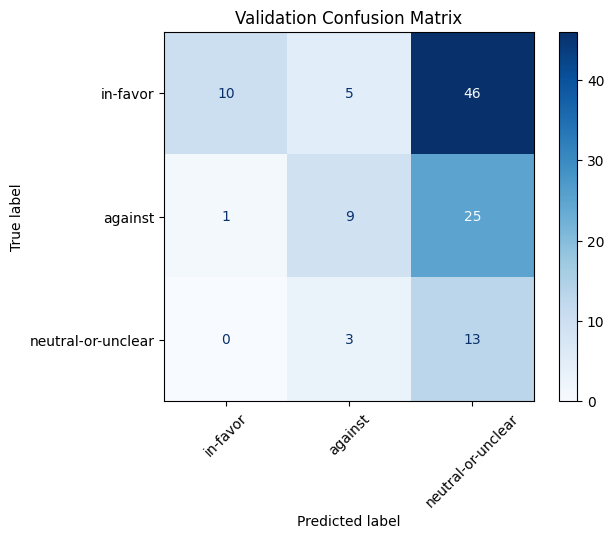

In [10]:
# Accuracy
labels = df["label_majority"]  # Make sure the true labels column is correctly named
correct = sum([
    pred == true
    for pred, true in zip(df["label_pred"], labels)
])
accuracy = correct / len(labels)
print(f"\nValidation Accuracy: {accuracy:.3f}")

# Confusion Matrix
try:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    cm = confusion_matrix(labels, df["label_pred"], labels=["in-favor", "against", "neutral-or-unclear"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["in-favor", "against", "neutral-or-unclear"])
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Validation Confusion Matrix")
    plt.show()
except ImportError:
    print("Install `scikit-learn` and `matplotlib` for confusion matrix support.")
